In [1]:
# import library
import os
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

os.makedirs("../docs", exist_ok=True)
os.makedirs("../models", exist_ok=True)

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

sns.set_theme(style="whitegrid")

print("✅ Cell 1 — Setup selesai")

✅ Cell 1 — Setup selesai


In [2]:
# load dataset
df = pd.read_csv("../data/all_stocks_5yr.csv", parse_dates=["date"])

print("=" * 50)
print("              INFORMASI DATASET")
print("=" * 50)
print(f"Total baris       : {len(df):,}")
print(f"Total kolom       : {df.shape[1]}")
print(f"Jumlah saham unik : {df['Name'].nunique()}")
print(f"Rentang tanggal   : {df['date'].min().date()} → {df['date'].max().date()}")
print("=" * 50)

display(df.head())

              INFORMASI DATASET
Total baris       : 619,040
Total kolom       : 7
Jumlah saham unik : 505
Rentang tanggal   : 2013-02-08 → 2018-02-07


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [3]:
# struktur data
print("Kolom dataset:")
print(df.columns.tolist())

print("\nTipe data:")
print(df.dtypes)

print("\nInfo dataset:")
df.info()

Kolom dataset:
['date', 'open', 'high', 'low', 'close', 'volume', 'Name']

Tipe data:
date      datetime64[us]
open             float64
high             float64
low              float64
close            float64
volume             int64
Name                 str
dtype: object

Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619040 non-null  datetime64[us]
 1   open    619029 non-null  float64       
 2   high    619032 non-null  float64       
 3   low     619032 non-null  float64       
 4   close   619040 non-null  float64       
 5   volume  619040 non-null  int64         
 6   Name    619040 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 33.1 MB


In [4]:
# missing value & duplikasi
print("Kolom dataset:")
print(df.columns.tolist())

print("\nTipe data:")
print(df.dtypes)

print("\nInfo dataset:")
df.info()

Kolom dataset:
['date', 'open', 'high', 'low', 'close', 'volume', 'Name']

Tipe data:
date      datetime64[us]
open             float64
high             float64
low              float64
close            float64
volume             int64
Name                 str
dtype: object

Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619040 non-null  datetime64[us]
 1   open    619029 non-null  float64       
 2   high    619032 non-null  float64       
 3   low     619032 non-null  float64       
 4   close   619040 non-null  float64       
 5   volume  619040 non-null  int64         
 6   Name    619040 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 33.1 MB


In [5]:
# statistik deskriptif
numeric_cols = ["open", "high", "low", "close", "volume"]

print("Statistik deskriptif kolom numerik:")
display(df[numeric_cols].describe().T)

Statistik deskriptif kolom numerik:


,count,mean,std,min,25%,50%,75%,max
open,619029.0,8.302333e+01,9.737877e+01,1.62,40.220,62.59,94.37,2.044000e+03
high,619032.0,8.377831e+01,9.820752e+01,1.69,40.620,63.15,95.18,2.067990e+03
low,619032.0,8.225610e+01,9.650742e+01,1.50,39.830,62.02,93.54,2.035110e+03
close,619040.0,8.304376e+01,9.738975e+01,1.59,40.245,62.62,94.41,2.049000e+03
volume,619040.0,4.321823e+06,8.693610e+06,0.00,1070320.500,2082093.50,4284509.25,6.182376e+08


Top 10 saham dengan data terbanyak:


Name
AAL     1259
AAPL    1259
AAP     1259
ABBV    1259
ABC     1259
ABT     1259
ACN     1259
ADBE    1259
ADI     1259
ADM     1259
Name: count, dtype: int64

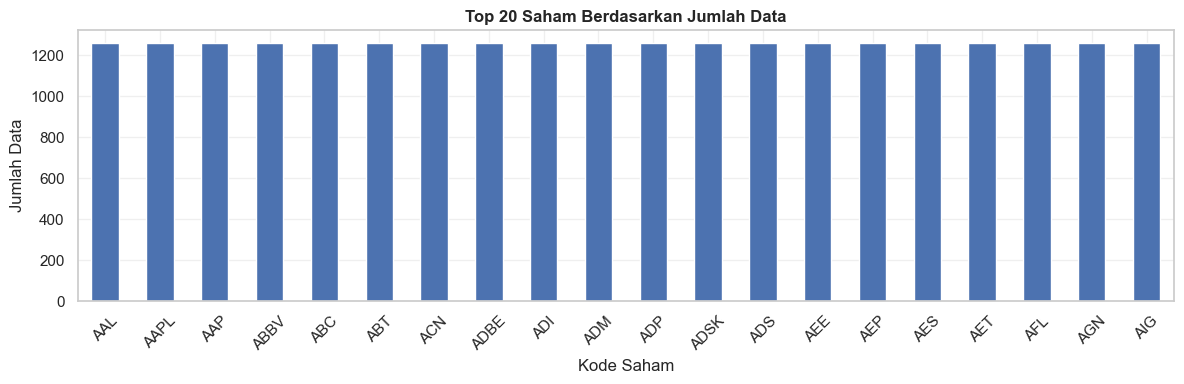

In [6]:
# jumlah data per saham
stock_counts = df["Name"].value_counts().sort_values(ascending=False)

print("Top 10 saham dengan data terbanyak:")
display(stock_counts.head(10))

plt.figure(figsize=(12, 4))
stock_counts.head(20).plot(kind="bar")
plt.title("Top 20 Saham Berdasarkan Jumlah Data", fontweight="bold")
plt.xlabel("Kode Saham")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../docs/top20_stock_counts.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# pilih saham untuk analisis
STOCK = "AAPL"   # ganti sesuai saham 

stock_df = (
    df[df["Name"] == STOCK]
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Saham yang dianalisis: {STOCK}")
print(f"Jumlah data          : {len(stock_df):,}")
print(f"Rentang tanggal      : {stock_df['date'].min().date()} → {stock_df['date'].max().date()}")

display(stock_df.head())
display(stock_df.tail())

Saham yang dianalisis: AAPL
Jumlah data          : 1,259
Rentang tanggal      : 2013-02-08 → 2018-02-07


,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


,date,open,high,low,close,volume,Name
1254,2018-02-01,167.165,168.62,166.7600,167.78,47230787,AAPL
1255,2018-02-02,166.000,166.80,160.1000,160.50,86593825,AAPL
1256,2018-02-05,159.100,163.88,156.0000,156.49,72738522,AAPL
1257,2018-02-06,154.830,163.72,154.0000,163.03,68243838,AAPL
1258,2018-02-07,163.085,163.40,159.0685,159.54,51608580,AAPL


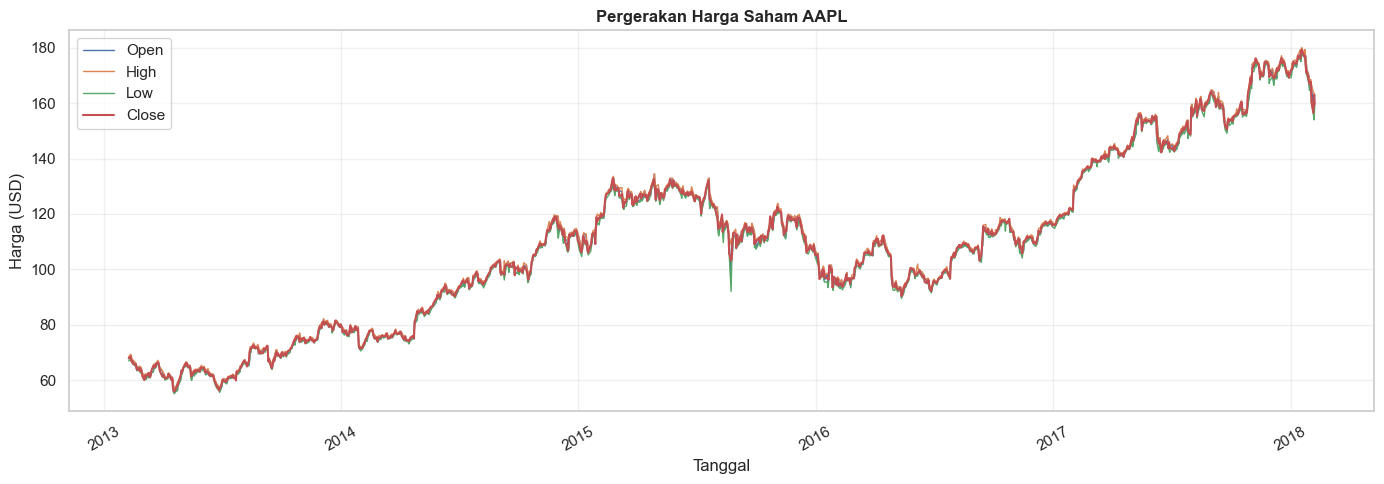

In [8]:
# pergerakan harga saham
plt.figure(figsize=(14, 5))

plt.plot(stock_df["date"], stock_df["open"], label="Open", linewidth=1)
plt.plot(stock_df["date"], stock_df["high"], label="High", linewidth=1)
plt.plot(stock_df["date"], stock_df["low"], label="Low", linewidth=1)
plt.plot(stock_df["date"], stock_df["close"], label="Close", linewidth=1.5)

plt.title(f"Pergerakan Harga Saham {STOCK}", fontweight="bold")
plt.xlabel("Tanggal")
plt.ylabel("Harga (USD)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"../docs/{STOCK}_price_movement.png", dpi=150, bbox_inches="tight")
plt.show()

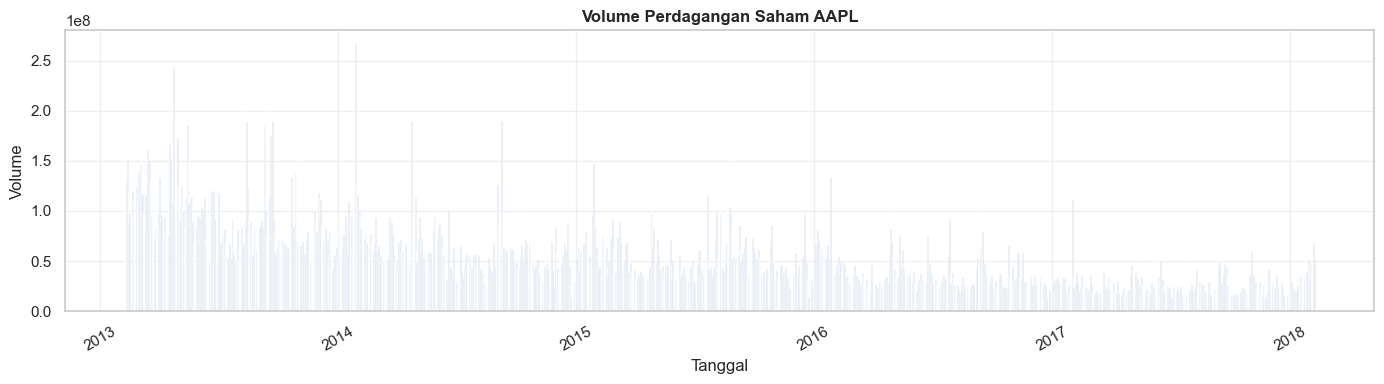

In [9]:
# volume perdagangan 
plt.figure(figsize=(14, 4))

plt.bar(stock_df["date"], stock_df["volume"], alpha=0.7)

plt.title(f"Volume Perdagangan Saham {STOCK}", fontweight="bold")
plt.xlabel("Tanggal")
plt.ylabel("Volume")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"../docs/{STOCK}_volume.png", dpi=150, bbox_inches="tight")
plt.show()

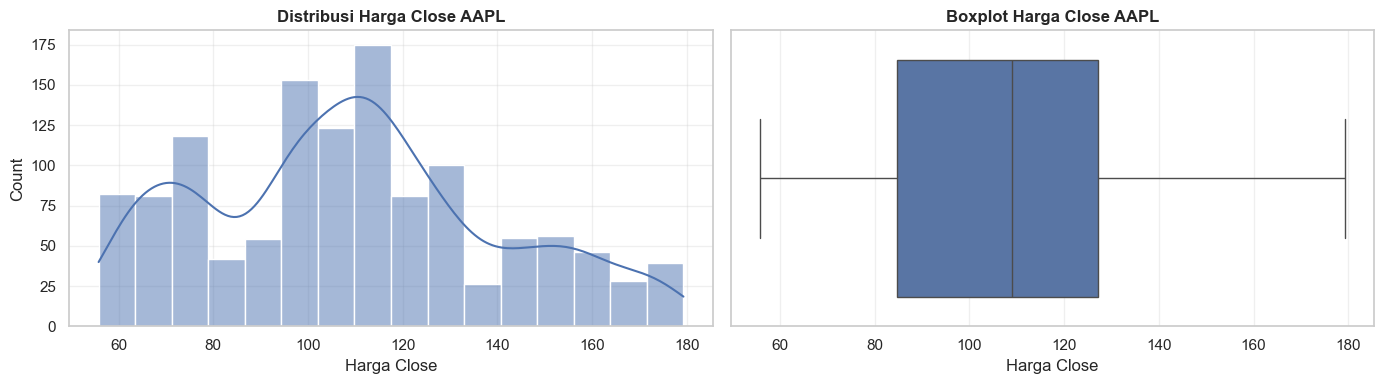

In [10]:
# distribusi harga penutupan
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(stock_df["close"], kde=True, ax=axes[0])
axes[0].set_title(f"Distribusi Harga Close {STOCK}", fontweight="bold")
axes[0].set_xlabel("Harga Close")

sns.boxplot(x=stock_df["close"], ax=axes[1])
axes[1].set_title(f"Boxplot Harga Close {STOCK}", fontweight="bold")
axes[1].set_xlabel("Harga Close")

plt.tight_layout()
plt.savefig(f"../docs/{STOCK}_close_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Statistik daily return:


count    1258.000000
mean        0.000786
std         0.014593
min        -0.079927
25%        -0.006397
50%         0.000435
75%         0.008631
max         0.081982
Name: daily_return, dtype: float64

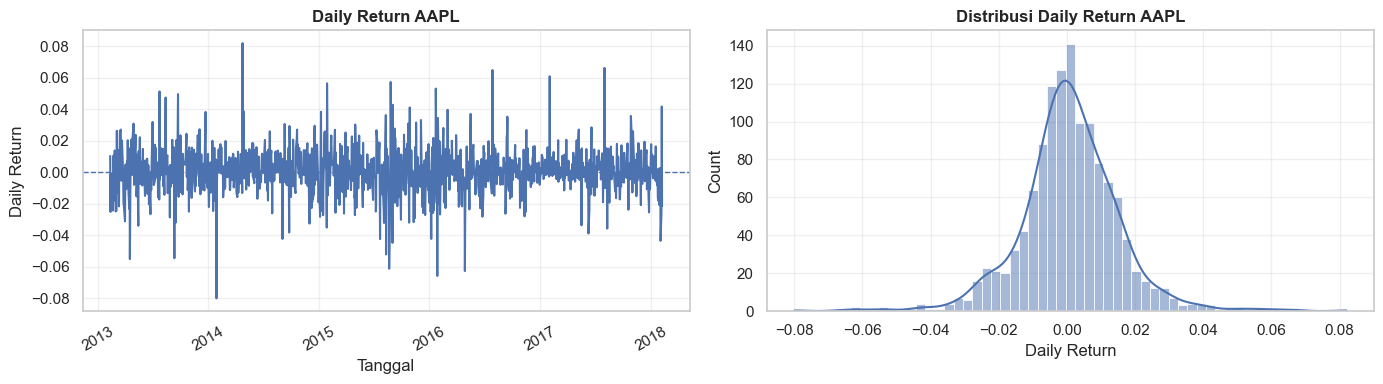

In [11]:
# return harian
stock_df["daily_return"] = stock_df["close"].pct_change()

print("Statistik daily return:")
display(stock_df["daily_return"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(stock_df["date"], stock_df["daily_return"])
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_title(f"Daily Return {STOCK}", fontweight="bold")
axes[0].set_xlabel("Tanggal")
axes[0].set_ylabel("Daily Return")
axes[0].tick_params(axis="x", rotation=30)

sns.histplot(stock_df["daily_return"].dropna(), kde=True, ax=axes[1])
axes[1].set_title(f"Distribusi Daily Return {STOCK}", fontweight="bold")
axes[1].set_xlabel("Daily Return")

plt.tight_layout()
plt.savefig(f"../docs/{STOCK}_daily_return.png", dpi=150, bbox_inches="tight")
plt.show()

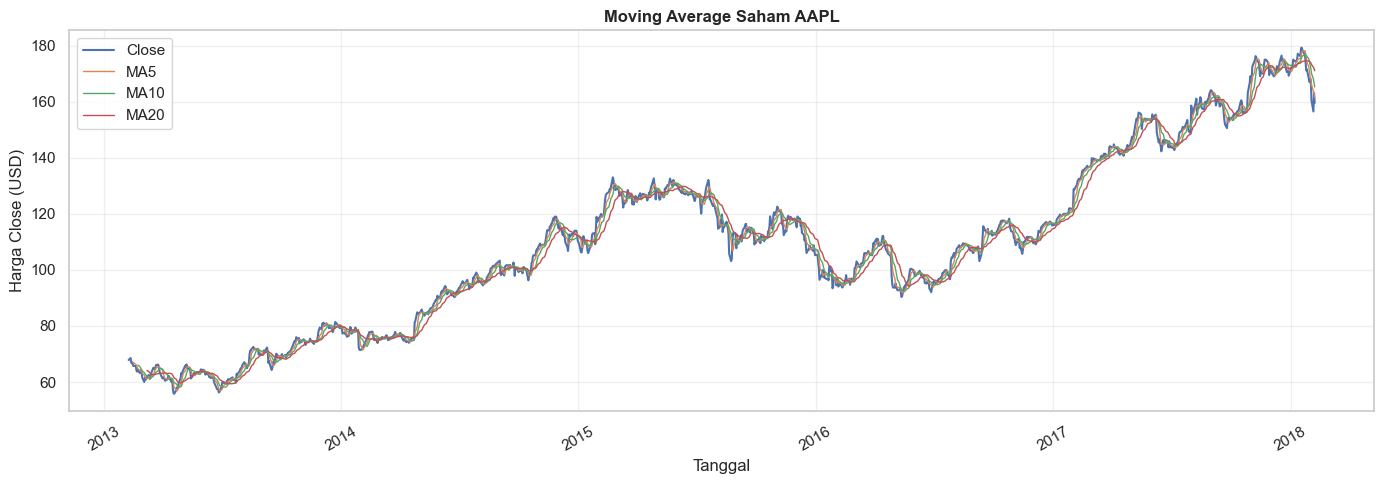

In [12]:
# rata rata pergerakan
stock_df["MA5"] = stock_df["close"].rolling(window=5).mean()
stock_df["MA10"] = stock_df["close"].rolling(window=10).mean()
stock_df["MA20"] = stock_df["close"].rolling(window=20).mean()

plt.figure(figsize=(14, 5))

plt.plot(stock_df["date"], stock_df["close"], label="Close", linewidth=1.5)
plt.plot(stock_df["date"], stock_df["MA5"], label="MA5", linewidth=1)
plt.plot(stock_df["date"], stock_df["MA10"], label="MA10", linewidth=1)
plt.plot(stock_df["date"], stock_df["MA20"], label="MA20", linewidth=1)

plt.title(f"Moving Average Saham {STOCK}", fontweight="bold")
plt.xlabel("Tanggal")
plt.ylabel("Harga Close (USD)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"../docs/{STOCK}_moving_average.png", dpi=150, bbox_inches="tight")
plt.show()

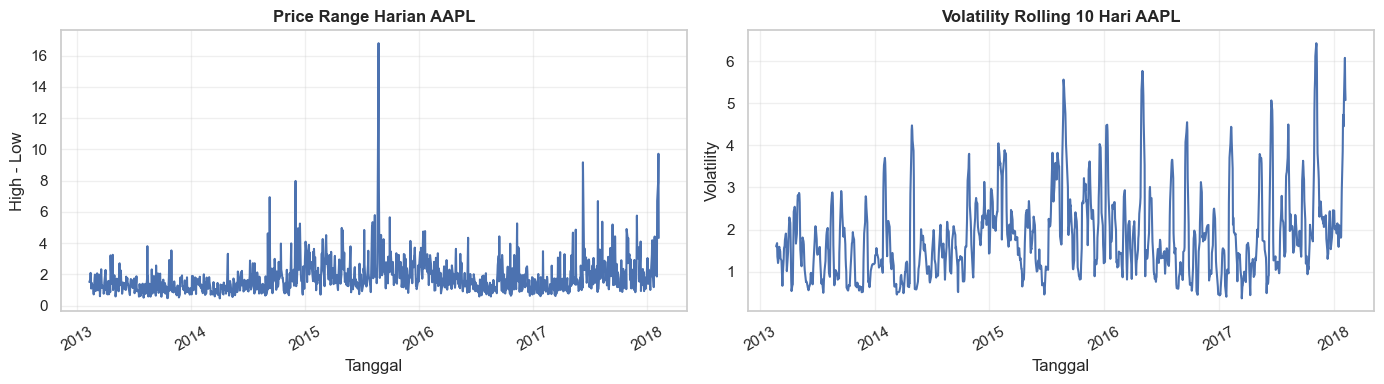

In [13]:
# pola & jarak harga
stock_df["price_range"] = stock_df["high"] - stock_df["low"]
stock_df["volatility"] = stock_df["close"].rolling(window=10).std()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(stock_df["date"], stock_df["price_range"])
axes[0].set_title(f"Price Range Harian {STOCK}", fontweight="bold")
axes[0].set_xlabel("Tanggal")
axes[0].set_ylabel("High - Low")
axes[0].tick_params(axis="x", rotation=30)

axes[1].plot(stock_df["date"], stock_df["volatility"])
axes[1].set_title(f"Volatility Rolling 10 Hari {STOCK}", fontweight="bold")
axes[1].set_xlabel("Tanggal")
axes[1].set_ylabel("Volatility")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"../docs/{STOCK}_volatility_price_range.png", dpi=150, bbox_inches="tight")
plt.show()

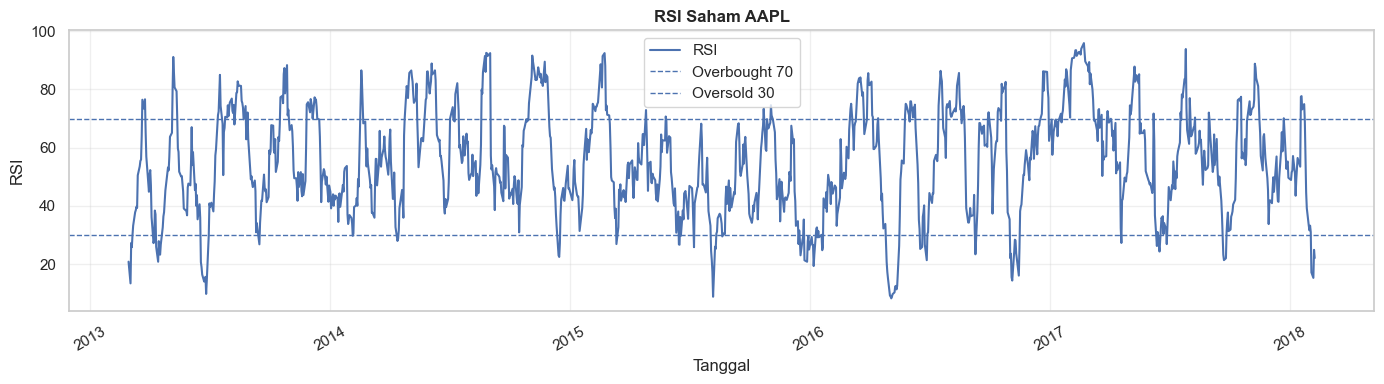

In [14]:
# RSI indicator
def calculate_rsi(series, period=14):
    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

stock_df["RSI"] = calculate_rsi(stock_df["close"], period=14)

plt.figure(figsize=(14, 4))

plt.plot(stock_df["date"], stock_df["RSI"], label="RSI", linewidth=1.5)
plt.axhline(70, linestyle="--", linewidth=1, label="Overbought 70")
plt.axhline(30, linestyle="--", linewidth=1, label="Oversold 30")

plt.title(f"RSI Saham {STOCK}", fontweight="bold")
plt.xlabel("Tanggal")
plt.ylabel("RSI")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"../docs/{STOCK}_rsi.png", dpi=150, bbox_inches="tight")
plt.show()

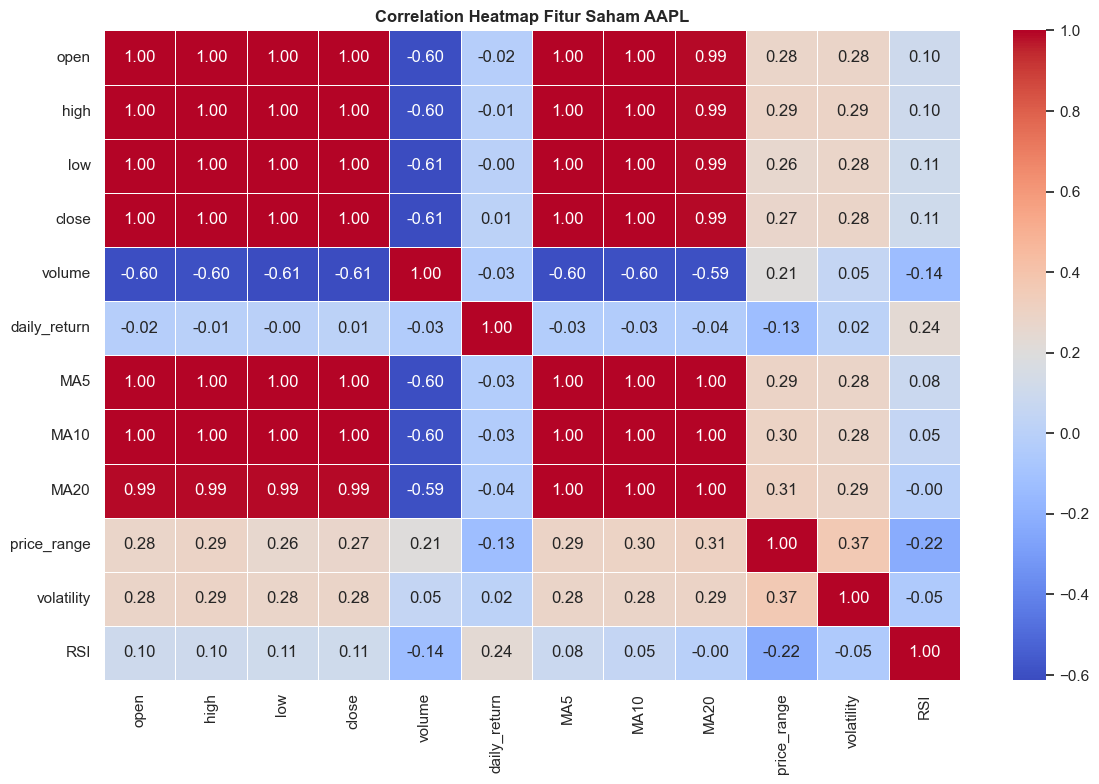

In [15]:
# korelasi antar fitur
corr_cols = [
    "open", "high", "low", "close", "volume",
    "daily_return", "MA5", "MA10", "MA20",
    "price_range", "volatility", "RSI"
]

corr_df = stock_df[corr_cols].dropna().corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title(f"Correlation Heatmap Fitur Saham {STOCK}", fontweight="bold")
plt.tight_layout()
plt.savefig(f"../docs/{STOCK}_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

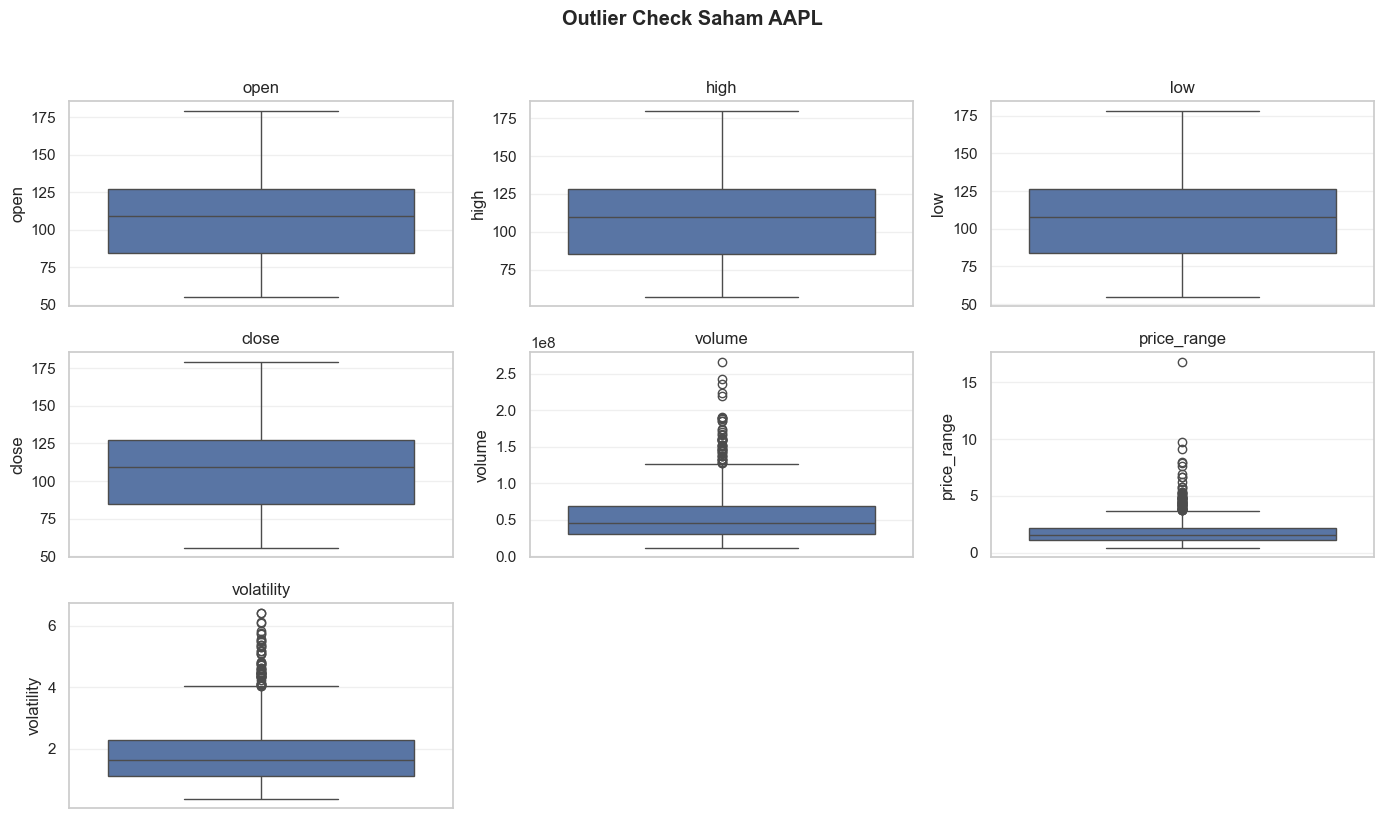

In [16]:
# outlier check
outlier_cols = ["open", "high", "low", "close", "volume", "price_range", "volatility"]

plt.figure(figsize=(14, 8))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=stock_df[col])
    plt.title(col)

plt.suptitle(f"Outlier Check Saham {STOCK}", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"../docs/{STOCK}_outlier_check.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# ringkasan EDA 
summary = {
    "stock": STOCK,
    "total_rows": len(stock_df),
    "start_date": stock_df["date"].min().date(),
    "end_date": stock_df["date"].max().date(),
    "min_close": stock_df["close"].min(),
    "max_close": stock_df["close"].max(),
    "mean_close": stock_df["close"].mean(),
    "std_close": stock_df["close"].std(),
    "mean_volume": stock_df["volume"].mean(),
    "mean_daily_return": stock_df["daily_return"].mean(),
    "mean_volatility": stock_df["volatility"].mean(),
    "mean_RSI": stock_df["RSI"].mean()
}

summary_df = pd.DataFrame([summary])

display(summary_df)

summary_df.to_csv(f"../docs/{STOCK}_eda_summary.csv", index=False)

print("✅ Ringkasan EDA tersimpan")
print(f"✅ File: docs/{STOCK}_eda_summary.csv")

,stock,total_rows,start_date,end_date,min_close,max_close,mean_close,std_close,mean_volume,mean_daily_return,mean_volatility,mean_RSI
0,AAPL,1259,2013-02-08,2018-02-07,55.7899,179.26,109.066698,30.556812,5.404790e+07,0.000786,1.857516,55.287504


✅ Ringkasan EDA tersimpan
✅ File: docs/AAPL_eda_summary.csv
